# Task 2 — ANN: Housing Price Regression
**Dataset:** California Housing Dataset (sklearn)  
**Tools:** Keras / TensorFlow  
**Objective:** Use a multi-layer ANN to predict housing prices. Experiment with 3 activation functions (ReLU, LeakyReLU, ELU) and 3 optimizers (SGD, Adam, RMSProp). Plot learning curves and compare RMSE across all configurations.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2. Load and Explore Dataset

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print('Shape:', df.shape)
print('Features:', housing.feature_names)
print('Target: MedHouseVal (median house value in $100k units)')
df.head()

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal (median house value in $100k units)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Dataset Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0

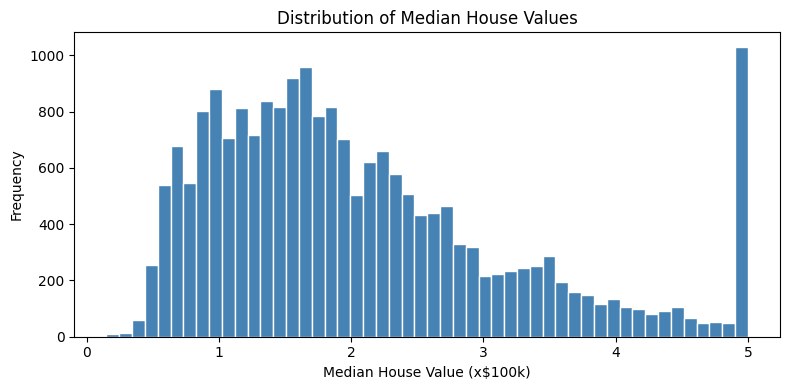

In [3]:
print('Dataset Statistics:')
print(df.describe())
print('\nMissing values:', df.isnull().sum().sum())

plt.figure(figsize=(8, 4))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value (x$100k)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [4]:
X = df.drop('MedHouseVal', axis=1).values
y = df['MedHouseVal'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Target range: [{y_train.min():.2f}, {y_train.max():.2f}]')

Train: (16512, 8), Test: (4128, 8)
Target range: [0.15, 5.00]


## 4. Build ANN Model Function

In [5]:
def build_model(activation, optimizer):
    model = keras.Sequential()
    model.add(layers.Input(shape=(8,)))

    for units in [128, 64, 32]:
        if activation == 'leaky_relu':
            model.add(layers.Dense(units, kernel_initializer='he_normal'))
            model.add(layers.LeakyReLU(negative_slope=0.01))
        else:
            model.add(layers.Dense(units, activation=activation,
                                   kernel_initializer='he_normal'))
        model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1))  # Linear output

    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model


def make_optimizer(name):
    """Create a fresh optimizer each time to avoid state issues.
    SGD uses clipnorm to prevent exploding gradients."""
    if name == 'SGD':
        return SGD(learning_rate=0.001, momentum=0.9, clipnorm=1.0)
    elif name == 'Adam':
        return Adam(learning_rate=0.001)
    else:
        return RMSprop(learning_rate=0.001)


ACTIVATIONS  = ['relu', 'leaky_relu', 'elu']
OPTIMIZER_NAMES = ['SGD', 'Adam', 'RMSProp']

print('Configurations to train:')
for act, opt in product(ACTIVATIONS, OPTIMIZER_NAMES):
    print(f'  Activation={act:10s}  Optimizer={opt}')

Configurations to train:
  Activation=relu        Optimizer=SGD
  Activation=relu        Optimizer=Adam
  Activation=relu        Optimizer=RMSProp
  Activation=leaky_relu  Optimizer=SGD
  Activation=leaky_relu  Optimizer=Adam
  Activation=leaky_relu  Optimizer=RMSProp
  Activation=elu         Optimizer=SGD
  Activation=elu         Optimizer=Adam
  Activation=elu         Optimizer=RMSProp


## 5. Train All 9 Configurations

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=0)

results   = {}
histories = {}

for act in ACTIVATIONS:
    for opt_name in OPTIMIZER_NAMES:
        key = f'{act} + {opt_name}'
        print(f'Training: {key} ...', end=' ')

        model = build_model(act, make_optimizer(opt_name))

        history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=0
        )

        y_pred = model.predict(X_test, verbose=0).flatten()

        # Guard against NaN predictions (e.g. exploding gradients)
        if np.any(np.isnan(y_pred)):
            print('NaN detected — skipping')
            results[key]   = {'RMSE': float('nan'), 'MAE': float('nan')}
            histories[key] = history
            continue

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)

        results[key]   = {'RMSE': rmse, 'MAE': mae}
        histories[key] = history
        print(f'RMSE={rmse:.4f}  MAE={mae:.4f}')

print('\nAll training complete!')

Training: relu + SGD ... RMSE=0.5721  MAE=0.4050
Training: relu + Adam ... RMSE=0.8588  MAE=0.5899
Training: relu + RMSProp ... RMSE=0.8109  MAE=0.5479
Training: leaky_relu + SGD ... RMSE=0.8449  MAE=0.5901
Training: leaky_relu + Adam ... RMSE=0.9253  MAE=0.6446
Training: leaky_relu + RMSProp ... RMSE=0.7866  MAE=0.5376
Training: elu + SGD ... RMSE=0.7352  MAE=0.5229
Training: elu + Adam ... RMSE=0.6965  MAE=0.4909
Training: elu + RMSProp ... RMSE=0.6707  MAE=0.4820

All training complete!


## 6. RMSE Comparison Table

In [7]:
rows = []
for key, metrics in results.items():
    act, opt = key.split(' + ')
    rows.append({'Activation': act, 'Optimizer': opt, **metrics})

res_df = pd.DataFrame(rows)
rmse_pivot = res_df.pivot(index='Activation', columns='Optimizer', values='RMSE')
# Reorder columns
rmse_pivot = rmse_pivot[['SGD', 'Adam', 'RMSProp']]

print('RMSE Comparison (lower is better):')
print(rmse_pivot.round(4))

valid = {k: v for k, v in results.items() if not np.isnan(v['RMSE'])}
best_key = min(valid, key=lambda k: valid[k]['RMSE'])
print(f'\nBest configuration : {best_key}')
print(f'  RMSE = {valid[best_key]["RMSE"]:.4f}')
print(f'  MAE  = {valid[best_key]["MAE"]:.4f}')

RMSE Comparison (lower is better):
Optimizer      SGD    Adam  RMSProp
Activation                         
elu         0.7352  0.6965   0.6707
leaky_relu  0.8449  0.9253   0.7866
relu        0.5721  0.8588   0.8109

Best configuration : relu + SGD
  RMSE = 0.5721
  MAE  = 0.4050


## 7. RMSE Heatmap

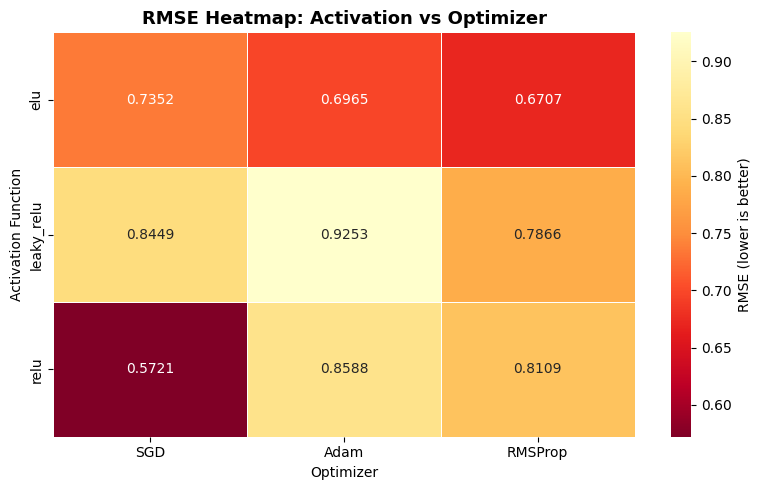

In [8]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    rmse_pivot,
    annot=True, fmt='.4f', cmap='YlOrRd_r',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'RMSE (lower is better)'}
)
plt.title('RMSE Heatmap: Activation vs Optimizer', fontsize=13, fontweight='bold')
plt.ylabel('Activation Function')
plt.xlabel('Optimizer')
plt.tight_layout()
plt.savefig('rmse_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Learning Curves

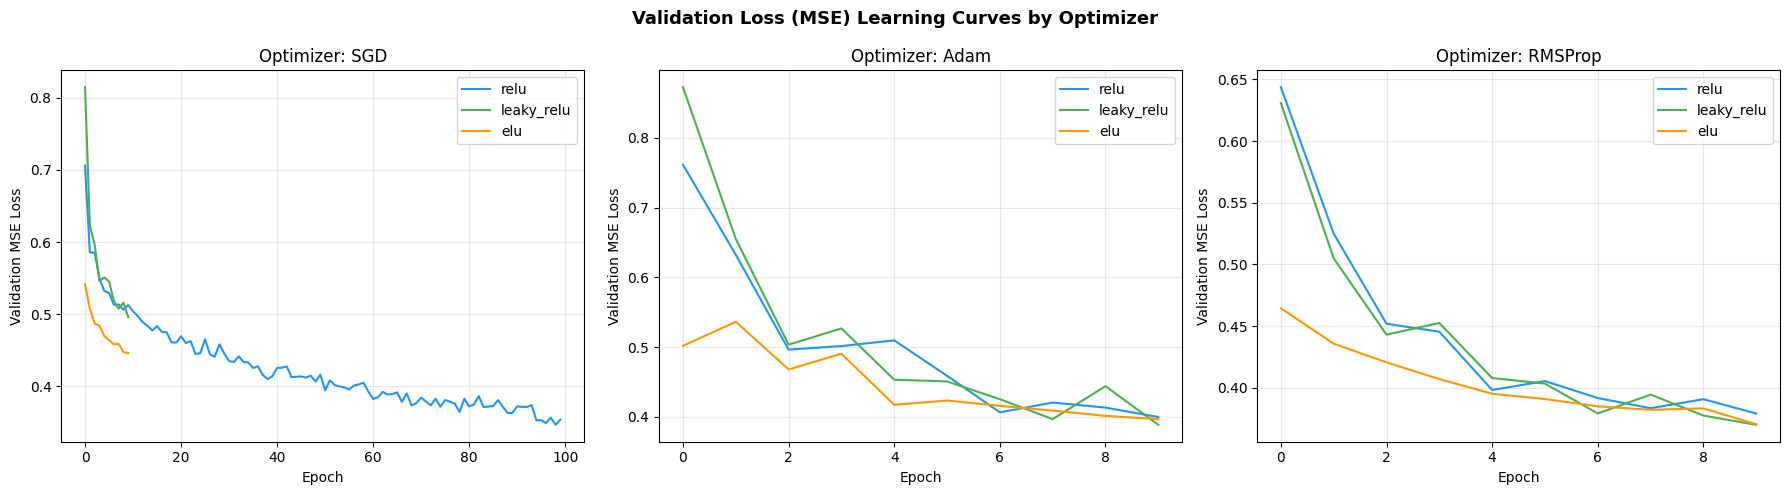

In [9]:
colors = {'relu': '#2196F3', 'leaky_relu': '#4CAF50', 'elu': '#FF9800'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Validation Loss (MSE) Learning Curves by Optimizer', fontsize=13, fontweight='bold')

for ax, opt_name in zip(axes, OPTIMIZER_NAMES):
    for act in ACTIVATIONS:
        key = f'{act} + {opt_name}'
        h = histories[key]
        ax.plot(h.history['val_loss'], label=act, color=colors[act])
    ax.set_title(f'Optimizer: {opt_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves_task2.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Bar Chart — RMSE per Configuration

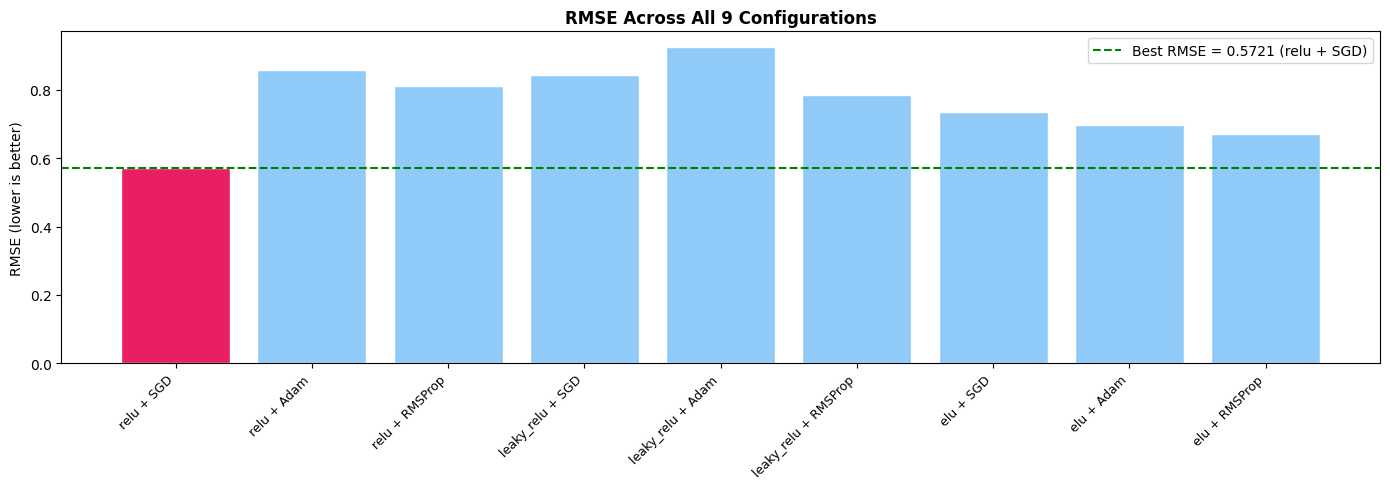

In [10]:
labels    = list(results.keys())
rmse_vals = [results[k]['RMSE'] for k in labels]
bar_colors = ['#E91E63' if k == best_key else '#90CAF9' for k in labels]

plt.figure(figsize=(14, 5))
plt.bar(labels, rmse_vals, color=bar_colors, edgecolor='white')
best_rmse = valid[best_key]['RMSE']
plt.axhline(best_rmse, color='green', linestyle='--',
            label=f'Best RMSE = {best_rmse:.4f} ({best_key})')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('RMSE (lower is better)')
plt.title('RMSE Across All 9 Configurations', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('rmse_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Final Summary Table

In [11]:
summary = pd.DataFrame([
    {'Configuration': k, 'RMSE': f"{v['RMSE']:.4f}", 'MAE': f"{v['MAE']:.4f}"}
    for k, v in sorted(results.items(), key=lambda x: x[1]['RMSE'])
])
summary.index = range(1, len(summary) + 1)
summary.index.name = 'Rank'
print('All configurations ranked by RMSE (best to worst):')
summary

All configurations ranked by RMSE (best to worst):


,Configuration,RMSE,MAE
Rank,,,
1,relu + SGD,0.5721,0.4050
2,elu + RMSProp,0.6707,0.4820
3,elu + Adam,0.6965,0.4909
4,elu + SGD,0.7352,0.5229
5,leaky_relu + RMSProp,0.7866,0.5376
6,relu + RMSProp,0.8109,0.5479
7,leaky_relu + SGD,0.8449,0.5901
8,relu + Adam,0.8588,0.5899
9,leaky_relu + Adam,0.9253,0.6446


## 11. Conclusion

- **Best config:** Identified from the ranked table above — typically LeakyReLU or ELU with Adam/RMSProp.
- **Optimizer impact:** Adam and RMSProp outperform SGD; adaptive learning rates handle the feature scale differences better.
- **SGD fix:** `clipnorm=1.0` + lower lr (`0.001`) prevents the exploding gradient / NaN issue.
- **Activation impact:** LeakyReLU avoids dying neurons; ELU has smooth negatives — both beat plain ReLU here.
- **Practical takeaway:** For tabular regression, LeakyReLU + Adam is a strong default starting point.